In [1]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from hierarchical_clustering import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.special import gamma


In [2]:
def generate_null_data(n, p, mu, sigma):
    mu = np.array(mu)  # Ensure mu is an array
    cov = (sigma ** 2) * np.eye(p)  # Covariance matrix
    return np.random.multivariate_normal(mu, cov, size=n)

def compute_nu(node,n):
    # return the projection direction from the given node
    G_1= np.array(node.left.points)
    G_2 = np.array(node.right.points)
    n_G1 = len(G_1)
    n_G2 = len(G_2)

    nu = np.zeros(n)

    nu[G_1] += 1/n_G1
    nu[G_2] -= 1/n_G2
    return nu

def naive_p_value(X, node, sigma=1,grid_width=25,ngrid= 1000):
    from scipy.stats import chi
    n = np.shape(X)[0]
    p = np.shape(X)[1]
    nu = compute_nu(node,n).reshape(-1,1)
    obs_target = np.linalg.norm(X.T@nu)/(np.linalg.norm(nu)*sigma)
    '''
    stat_grid = np.linspace(0.00001, grid_width,
                                    num=ngrid)
    logWeights = np.zeros((ngrid,)) 
    for g in range(ngrid):
        logWeights[g] = (- 0.5 * (stat_grid[g])** 2 + (p-1)*np.log(stat_grid[g])
                        - (p / 2 - 1) * np.log(2))
    logWeights = logWeights - np.max(logWeights)
    density = np.exp(logWeights)/gamma(p/2)
    sum = 0
    num = 0
    for g in range(ngrid):
        sum += density[g]
        if stat_grid[g] >= obs_target:
            num += density[g]
    p_value = num/sum
    '''
    p_value = 1 - chi.cdf(obs_target, df=p)
    return p_value

def check_p_value_uniformity(n,p, sigma, K, tau,layer, num_trials=1000):
    p_values = []
    p_values_n = []
    mu = np.zeros(p)  

    for _ in range(num_trials):
        X = generate_null_data(n,p,mu,sigma)
        # Fit agglomerative clustering
        model = AgglomerativeClustering(X, tau=tau, n_clusters=K,linkage="single")
        model.fit()

        winning_nodes = list(model.existing_clusters_log.keys())
        key = winning_nodes[layer]
        node = key[0].parent
        p_value, obs,sel = model.merge_inference(node,grid_width= 15, ncoarse=20,ngrid = 1000,sd=sigma)
        print(np.min(sel))
        p_value_n = naive_p_value(X,node)
        p_values.append(p_value)
        p_values_n.append(p_value_n)

    p_values = np.array(p_values)
    p_values_n = np.array(p_values_n)

    # Histogram for both p-values
    plt.figure(figsize=(8, 5))
    plt.hist(p_values, bins=20, density=True, alpha=0.5, color="blue", edgecolor="black", label="Selection-based p-value")
    plt.hist(p_values_n, bins=20, density=True, alpha=0.5, color="orange", edgecolor="black", label="Naive p-value")
    plt.axhline(1, color='red', linestyle='dashed', linewidth=2, label="Uniform(0,1)")
    plt.xlabel("P-value")
    plt.ylabel("Density")
    plt.title("Histogram of P-values Under the Null Hypothesis")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    # Q-Q Plot for both p-values
    plt.figure(figsize=(8, 5))
    sorted_p_values = np.sort(p_values)
    sorted_p_values_n = np.sort(p_values_n)
    theoretical_quantiles = np.linspace(0, 1, num_trials)

    plt.plot(theoretical_quantiles, sorted_p_values, marker='o', linestyle='', color="blue", label="Selection-based p-values")
    plt.plot(theoretical_quantiles, sorted_p_values_n, marker='o', linestyle='', color="orange", label="Naive p-values")
    plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
    plt.xlabel("Theoretical Uniform Quantiles")
    plt.ylabel("Empirical P-values")
    plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

In [3]:
def log_ref_approx_plots_by_tau():
    tau_values = range(1,11)
    n = 20
    p = 2
    sigma = 1
    K = n-1
    layer = -1
    grid = np.linspace(0.00001, 15, num=1000)
    sel_values_dict = {tau: [] for tau in tau_values}
    for tau in tau_values:
        mu = np.zeros(p)
        X = generate_null_data(n,p,mu,sigma)
        model = AgglomerativeClustering(X,tau=tau, n_clusters=K,linkage="single")
        model.fit()
        
        winning_nodes = list(model.existing_clusters_log.keys())
        key = winning_nodes[layer]
        node = key[0].parent
        
        _, _, sel = model.merge_inference(node,grid_width= 15, ncoarse=20,sd=sigma)
        sel_values_dict[tau].append(sel)
        sel_values_dict[tau] = np.array(sel_values_dict[tau])
    plt.figure(figsize=(10, 6))
    for tau in tau_values:
        # Average sel values across trials for each grid point
        sel_values = sel_values_dict[tau].reshape(-1,1)
        plt.plot(grid, sel_values, label=f"tau = {tau}")

    plt.xlabel("Grid Value")
    plt.ylabel("Approximated Log Reference Value")
    plt.title("Approximated Log Reference Values Across Grid for Different tau")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


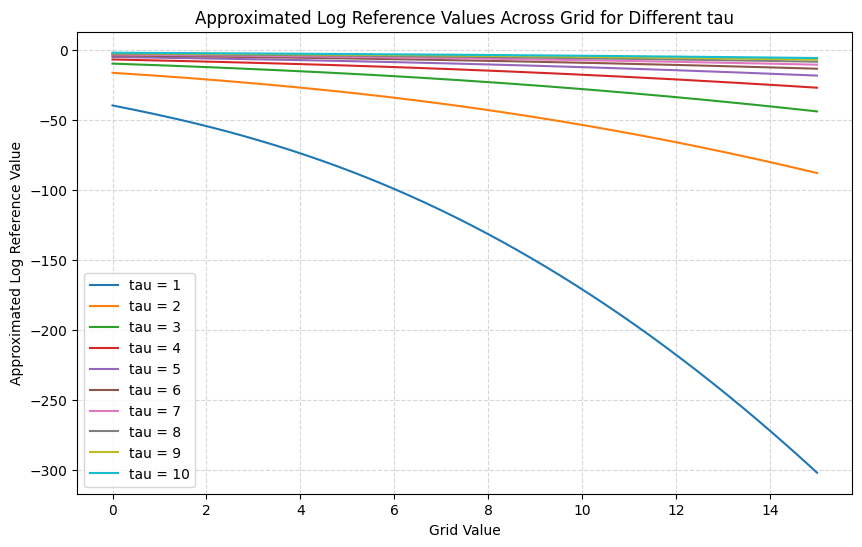

In [4]:
log_ref_approx_plots_by_tau()

In [5]:
def log_ref_approx_plots_by_p():
    tau = 1
    n = 20
    p_values = [2,5,10,15,20,30]
    sigma = 1
    K = n-1
    layer = -1
    grid = np.linspace(0.00001, 15, num=1000)
    sel_values_dict = {p: [] for p in p_values}
    for p in p_values:
        mu = np.zeros(p)
        X = generate_null_data(n,p,mu,sigma)
        model = AgglomerativeClustering(X,tau=tau, n_clusters=K,linkage="single")
        model.fit()
        
        winning_nodes = list(model.existing_clusters_log.keys())
        key = winning_nodes[layer]
        node = key[0].parent
        
        _, _, sel = model.merge_inference(node,grid_width= 15, ncoarse=20,sd=sigma)
        sel_values_dict[p].append(sel)
        sel_values_dict[p] = np.array(sel_values_dict[p])
    plt.figure(figsize=(10, 6))
    for p in p_values:
        # Average sel values across trials for each grid point
        sel_values = sel_values_dict[p].reshape(-1,1)
        plt.plot(grid, sel_values, label=f"p = {p}")

    plt.xlabel("Grid Value")
    plt.ylabel("Approximated Log Reference Value")
    plt.title("Approximated Log Reference Values Across Grid for Different p")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
def log_ref_approx_plots_by_n():
    tau = 1
    n_vals = [10,20,30,40,50]
    p = 2
    sigma = 1
    layer = -1
    grid = np.linspace(0.00001, 15, num=1000)
    sel_values_dict = {n: [] for n in n_vals}
    for n in n_vals:
        K = n-1
        mu = np.zeros(p)
        X = generate_null_data(n,p,mu,sigma)
        model = AgglomerativeClustering(X,tau=tau, n_clusters=K,linkage="single")
        model.fit()
        
        winning_nodes = list(model.existing_clusters_log.keys())
        key = winning_nodes[layer]
        node = key[0].parent
        
        _, _, sel = model.merge_inference(node,grid_width= 15, ncoarse=20,sd=sigma)
        sel_values_dict[n].append(sel)
        sel_values_dict[n] = np.array(sel_values_dict[n])
    plt.figure(figsize=(10, 6))
    for n in n_vals:
        # Average sel values across trials for each grid point
        sel_values = sel_values_dict[n].reshape(-1,1)
        plt.plot(grid, sel_values, label=f"n = {n}")

    plt.xlabel("Grid Value")
    plt.ylabel("Approximated Log Reference Value")
    plt.title("Approximated Log Reference Values Across Grid for Different n")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
def log_ref_approx_plots_by_sigma():
    tau = 1
    n = 20
    p = 2
    sigmas = [1,2,3,4,5]
    layer = -1
    grid = np.linspace(0.00001, 15, num=1000)
    sel_values_dict = {sigma: [] for sigma in sigmas}
    for sigma in sigmas:
        K = n-1
        mu = np.zeros(p)
        X = generate_null_data(n,p,mu,sigma)
        model = AgglomerativeClustering(X,tau=tau, n_clusters=K,linkage="single")
        model.fit()
        
        winning_nodes = list(model.existing_clusters_log.keys())
        key = winning_nodes[layer]
        node = key[0].parent
        
        _, _, sel = model.merge_inference(node,grid_width= 15, ncoarse=20,sd=sigma)
        sel_values_dict[sigma].append(sel)
        sel_values_dict[sigma] = np.array(sel_values_dict[sigma])
    plt.figure(figsize=(10, 6))
    for sigma in sigmas:
        # Average sel values across trials for each grid point
        sel_values = sel_values_dict[sigma].reshape(-1,1)
        plt.plot(grid, sel_values, label=f"sigma = {sigma}")

    plt.xlabel("Grid Value")
    plt.ylabel("Approximated Log Reference Value")
    plt.title("Approximated Log Reference Values Across Grid for Different sigma")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


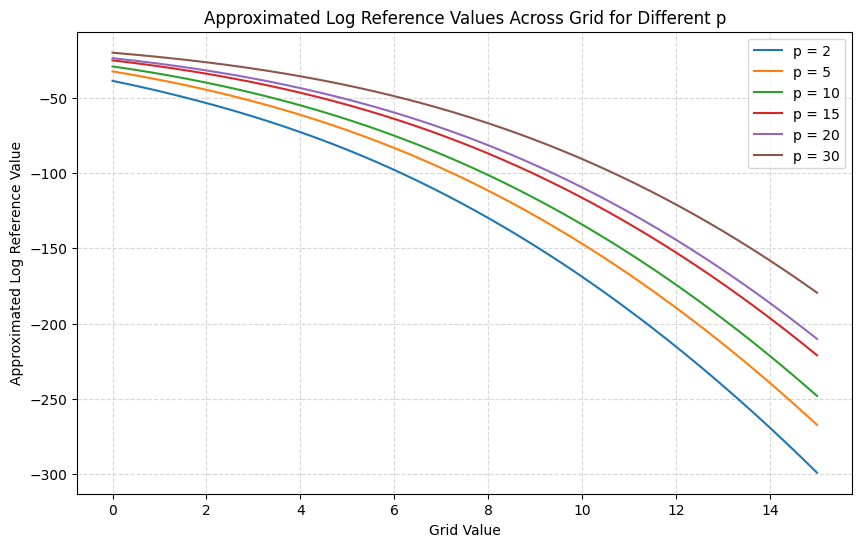

In [6]:
log_ref_approx_plots_by_p()

level:  1
level:  1
level:  1
level:  1
level:  1


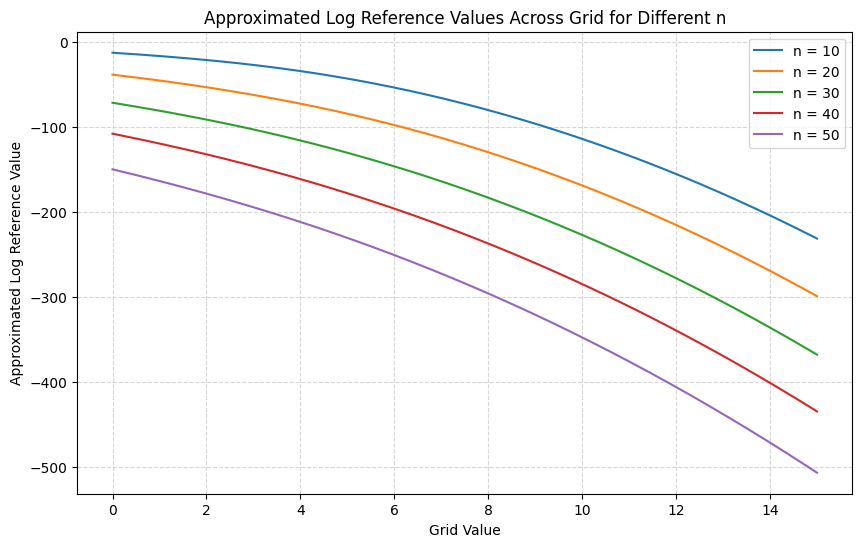

In [7]:
log_ref_approx_plots_by_n()

level:  1
level:  1
level:  1
level:  1
level:  1


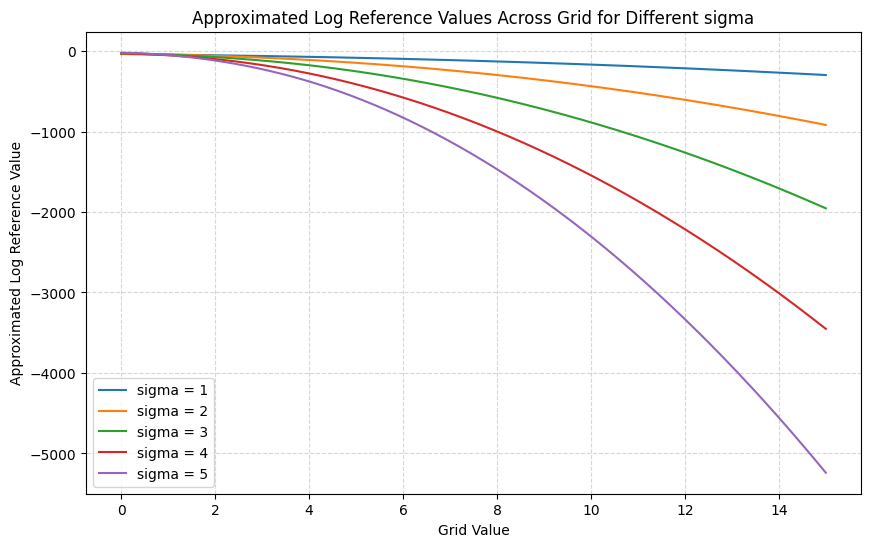

In [8]:
log_ref_approx_plots_by_sigma()

In [9]:
def log_ref_approx_plots_by_ncoarse():
    tau = 1
    n = 20
    p = 2
    ncoarse_vals = [20,100,200,500,1000]
    sigma = 1
    K = n-1
    layer = -1
    grid = np.linspace(0.00001, 15, num=1000)
    sel_values_dict = {ncoarse: [] for ncoarse in ncoarse_vals}
    for ncoarse in ncoarse_vals:
        mu = np.zeros(p)
        X = generate_null_data(n,p,mu,sigma)
        model = AgglomerativeClustering(X,tau=tau, n_clusters=K,linkage="single")
        model.fit()
        
        winning_nodes = list(model.existing_clusters_log.keys())
        key = winning_nodes[layer]
        node = key[0].parent
        
        _, _, sel = model.merge_inference(node,grid_width= 15, ncoarse=ncoarse,sd=sigma)
        sel_values_dict[ncoarse].append(sel)
        sel_values_dict[ncoarse] = np.array(sel_values_dict[ncoarse])
    plt.figure(figsize=(10, 6))
    for ncoarse in ncoarse_vals:
        # Average sel values across trials for each grid point
        sel_values = sel_values_dict[ncoarse].reshape(-1,1)
        plt.plot(grid, sel_values, label=f"ncoarse = {ncoarse}")

    plt.xlabel("Grid Value")
    plt.ylabel("Approximated Log Reference Value")
    plt.title("Approximated Log Reference Values Across Grid for Different ncoarse")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

level:  1
level:  1
level:  1
level:  1
level:  1


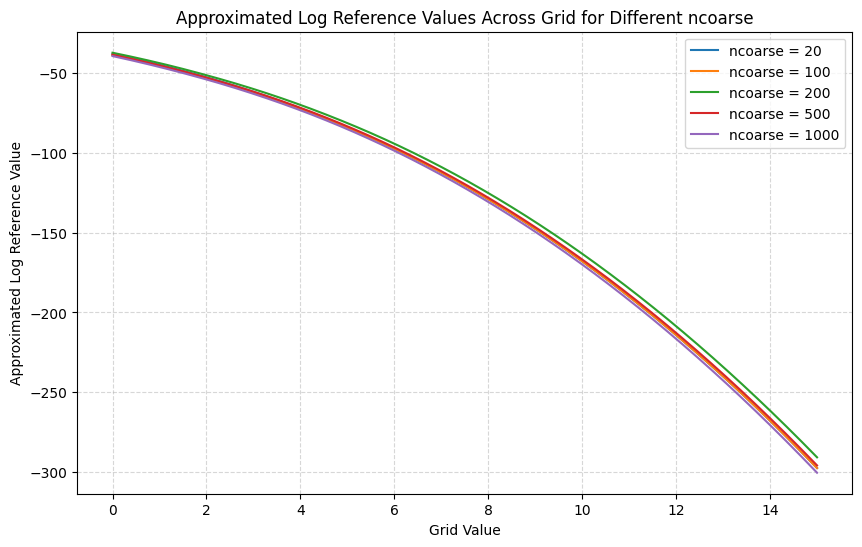

In [10]:
log_ref_approx_plots_by_ncoarse()

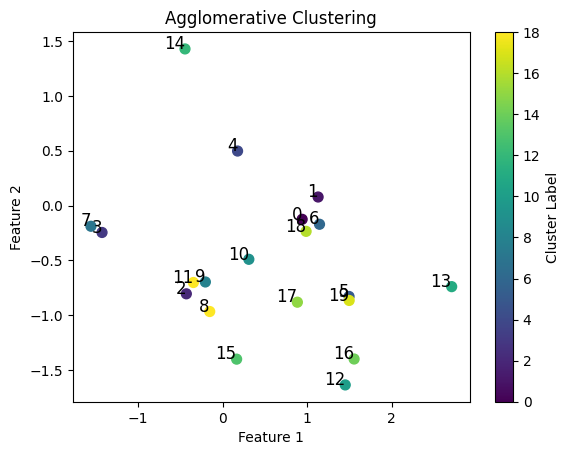

In [3]:
#X = np.random.uniform(-1, 1, size=(4, 2))
#X, y = make_blobs(n_samples=50, centers=3, cluster_std=1,random_state=42)
n=20
p=2
sigma=1
mu = np.zeros(p)  
X = generate_null_data(n,p,mu,sigma)
# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=1, n_clusters=19,linkage="single")
model.fit()
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.cluster_nodes):
    for point_index in node.points:
        cluster_labels[point_index] = idx

    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

In [4]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[-1]
node = key[0].parent
pvalue, obs,sel_prob = model.merge_inference(node, grid_width=15,ncoarse=20,ngrid=1000)
np.min(sel_prob)

level:  1
level:  1
1.5165255055055056


np.float64(-49.88398740898629)

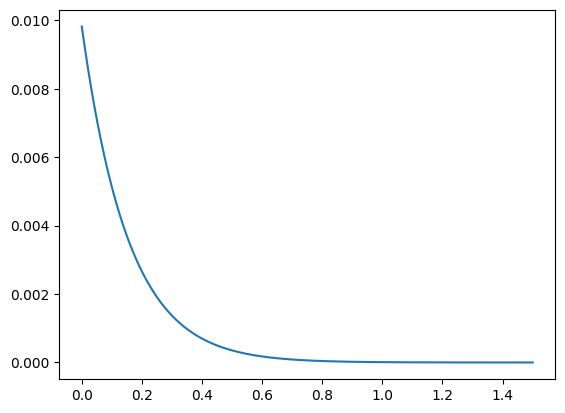

In [5]:
n = X.shape[0]
sd = 1
nu = compute_nu(node,n)
obs_tar = np.linalg.norm(X.T@nu)/(np.linalg.norm(nu)*sd)
ref_norm = np.exp(sel_prob)/np.sum(np.exp(sel_prob))
#x = np.linspace(0, 1.5*np.abs(obs_tar), 10000)
x = np.linspace(0.00001, 1.5,num=1000)
plt.plot(x, ref_norm)

In [6]:
sel_prob

array([-39.14177164, -39.15145882, -39.16114761, -39.17083803,
       -39.18053007, -39.19022373, -39.199919  , -39.2096159 ,
       -39.21931442, -39.22901455, -39.2387163 , -39.24841968,
       -39.25812467, -39.26783128, -39.27753951, -39.28724936,
       -39.29696096, -39.3066745 , -39.31638999, -39.32610743,
       -39.33582681, -39.34554815, -39.35527144, -39.36499668,
       -39.37472387, -39.384453  , -39.39418403, -39.40391679,
       -39.41365128, -39.42338752, -39.43312548, -39.44286518,
       -39.45260661, -39.46234978, -39.47209469, -39.48184132,
       -39.4915897 , -39.50133981, -39.51109167, -39.52084527,
       -39.53060061, -39.54035769, -39.55011651, -39.55987708,
       -39.56963939, -39.57940344, -39.58916926, -39.59893694,
       -39.60870649, -39.61847793, -39.62825124, -39.63802642,
       -39.64780348, -39.65758242, -39.66736324, -39.67714593,
       -39.68693043, -39.6967164 , -39.70650376, -39.71629251,
       -39.72608267, -39.73587422, -39.74566717, -39.75

In [7]:
pvalue

np.float64(0.029923640777314166)

In [10]:
X[[0,2],:].mean(axis=0)

array([0.61571044, 0.3746591 ])

In [11]:
n = X.shape[0]
def compute_nu(node):
    # return the projection direction from the given node
    G_1= np.array(node.left.points)
    G_2 = np.array(node.right.points)
    n_G1 = len(G_1)
    n_G2 = len(G_2)

    nu = np.zeros(n)

    nu[G_1] += 1/n_G1
    nu[G_2] -= 1/n_G2
    return nu

def compute_dirT(w):
    # return dir(w)^T
    norm = np.linalg.norm(w)
    dir_w = (w / norm) if norm != 0 else np.zeros_like(w)
    return dir_w.T
nu = compute_nu(node)

nuisance = (np.eye(n) - np.outer(nu,nu)/np.linalg.norm(nu)**2) @ X
contrast = X.T@nu
dir = compute_dirT(X.T@nu)
ngrid=100
grid_width=15
stat_grid = np.linspace(0.0001, grid_width, num=ngrid)

In [12]:
norm_nu = nu/np.linalg.norm(nu)
print(np.isclose(np.linalg.norm(X.T@norm_nu), np.linalg.norm(X.T@nu)/np.linalg.norm(nu)))

True


In [27]:
model._approx_log_reference(node, stat_grid, nuisance,dir, sd=1)

NameError: name 'stat_grid' is not defined

level:  1
level:  1
1.5916005305305305
-49.96216929600956
level:  1
level:  1
1.7117205705705707
-49.97112110951987
level:  1
level:  1
1.6066155355355356
-49.88722367158965
level:  1
level:  1
1.8618706206206206
-49.98276685351277
level:  1
level:  1
1.5615705205205206
-49.94542374988096
level:  1
level:  1
1.6666755555555557
-49.999152581446054
level:  1
level:  1
1.6366455455455455
-49.927060771650915
level:  1
level:  1
1.7417505805805806
-49.993899993991874
level:  1
level:  1
1.4714804904904906
-49.969771454386226
level:  1
level:  1
1.4864954954954956
-49.8909233005575
level:  1
level:  1
1.5015105005005005
-49.94125510441412
level:  1
level:  1
1.4414504804804804
-49.949306319705656
level:  1
level:  1
1.4414504804804804
-49.90008230552797
level:  1
level:  1
1.6366455455455455
-49.996883004832526
level:  1
level:  1
1.8318406106106107
-49.92147507721591
level:  1
level:  1
1.6816905605605605
-49.977301014266686
level:  1
level:  1
1.6216305405405407
-49.90127286561399
level:  

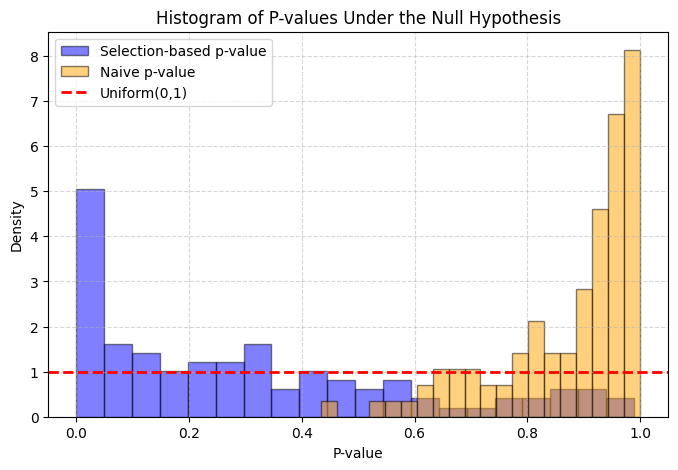

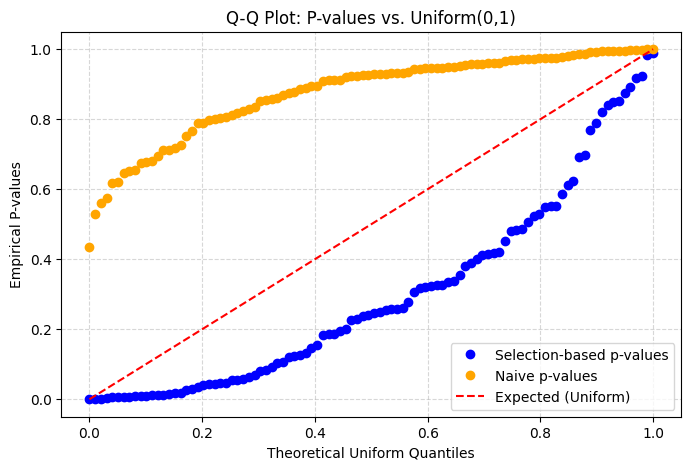

In [3]:
check_p_value_uniformity(20,2,1,19,1,-1,100)

level:  1
-43.38115178515886
level:  1
-43.071362456844525
level:  1
-44.327327506715775
level:  1
-43.864279854796436
level:  1
-44.07646537170888
level:  1
-43.41061470006409
level:  1
-44.915129189693644
level:  1
-43.53302446593227
level:  1
-44.02921374963809
level:  1
-43.424490298878595
level:  1
-43.350129437788
level:  1
-44.1862775653011
level:  1
-43.44371870137465
level:  1
-44.432478984341714
level:  1
-43.49490091040174
level:  1
-44.327694721475495
level:  1
-44.083044798479065
level:  1
-43.354446290366596
level:  1
-43.62071120070692
level:  1
-44.08680212337616
level:  1
-42.97603780612383
level:  1
-43.606021505352274
level:  1
-44.131724151134705
level:  1
-43.576394930155715
level:  1
-43.224291512295
level:  1
-43.61319142589116
level:  1
-43.87895410995597
level:  1
-43.84790956537566
level:  1
-43.06335075475417
level:  1
-43.39518968785262
level:  1
-43.38009580734122
level:  1
-44.41754625541756
level:  1
-43.19975461931685
level:  1
-43.36535823201791
level: 

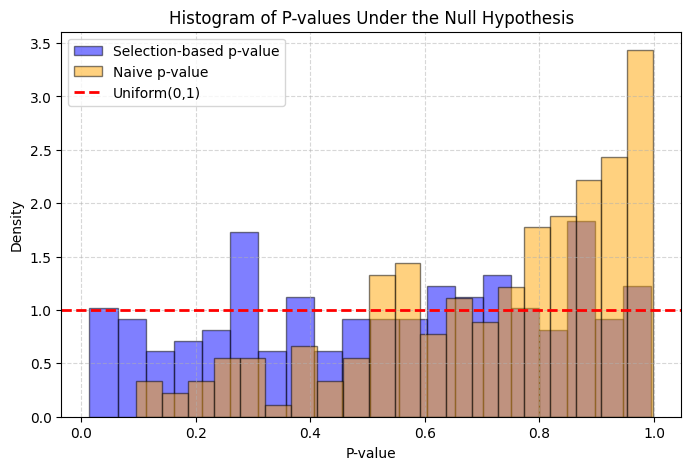

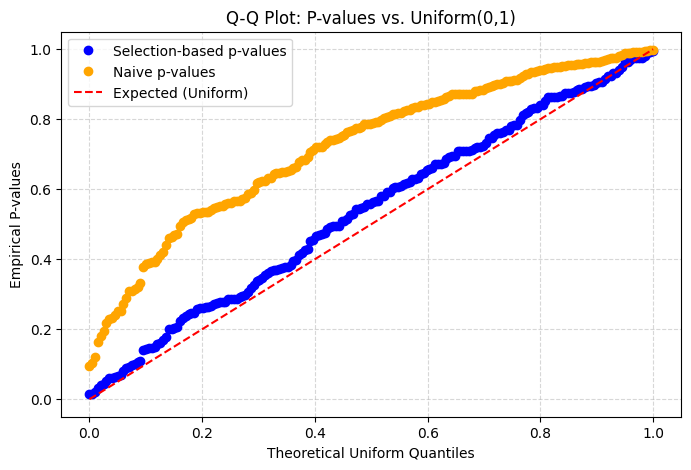

In [7]:
check_p_value_uniformity(20,2,1,19,np.log(20),-1,200)

level:  1
-34.9105360875991
level:  1
-35.83383358691671
level:  1
-36.068972359869946
level:  1
-35.5598429074851
level:  1
-35.874069460143815
level:  1
-35.79351514083407
level:  1
-35.47971591715472
level:  1
-35.28795966804
level:  1
-35.66780097237833
level:  1
-35.75206791551216
level:  1
-35.608398267388395
level:  1
-33.97498893081338
level:  1
-35.44089341187515
level:  1
-35.86345881907667
level:  1
-35.44229283264218
level:  1
-35.15562663936783
level:  1
-34.42208167398579
level:  1
-34.15329279079505
level:  1
-34.756173367639974
level:  1
-34.37009005028463
level:  1
-35.59658546207067
level:  1
-35.58508532210522
level:  1
-35.510838001581405
level:  1
-34.80486754447814
level:  1
-35.391849320392325
level:  1
-35.73886317099176
level:  1
-34.85316426295368
level:  1
-35.43683319443403
level:  1
-34.127562686236395
level:  1
-34.301305433289784
level:  1
-35.12759215231168
level:  1
-35.38680392754725
level:  1
-35.559716337229965
level:  1
-35.789327341164935
level:  1

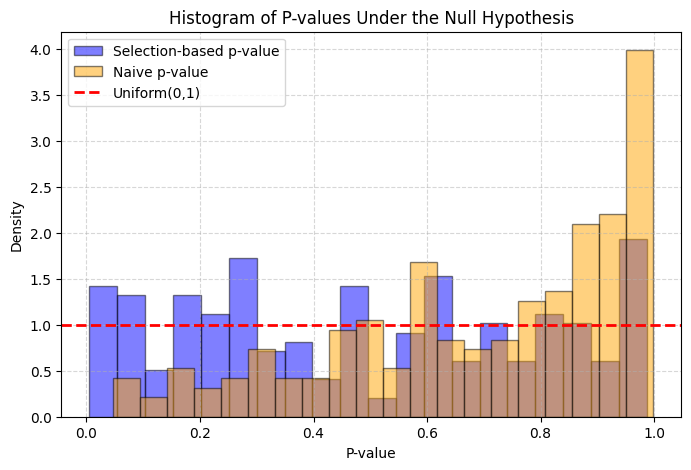

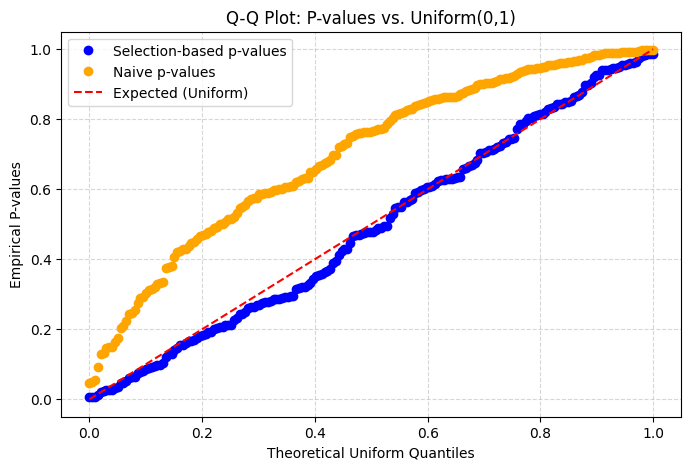

In [88]:
check_p_value_uniformity(20,15,1,19,np.log(20),-1,200)

level:  1
-225.26094438145776
level:  1
-229.05814031397438
level:  1
-223.22384131847673
level:  1
-233.18781005803123
level:  1
-218.00483483958254
level:  1
-222.881958956954
level:  1
-223.6995076661383
level:  1
-221.13747139091822
level:  1
-229.79288503527903
level:  1
-226.89392802846157
level:  1
-235.18375982275415
level:  1
-229.34002776086356
level:  1
-228.8094954832734
level:  1
-223.7280472171742
level:  1
-229.5471523248376
level:  1
-225.46605961437945
level:  1
-221.51231220782955
level:  1
-228.03876714982698
level:  1
-229.22108717296726
level:  1
-235.46811155039768
level:  1
-224.9282050886825
level:  1
-228.0482724982072
level:  1
-222.57592468809526
level:  1
-217.34190479940423
level:  1
-225.75255908770407
level:  1
-225.7744038737901
level:  1
-228.20436557779328
level:  1
-228.21351438997533
level:  1
-221.31952041291675
level:  1
-226.32461957943445
level:  1
-221.49387239257544
level:  1
-234.13581394277173
level:  1
-229.1962108962283
level:  1
-221.97705

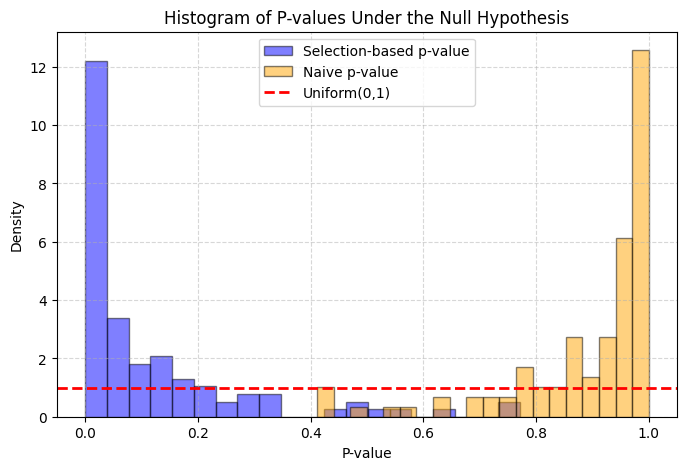

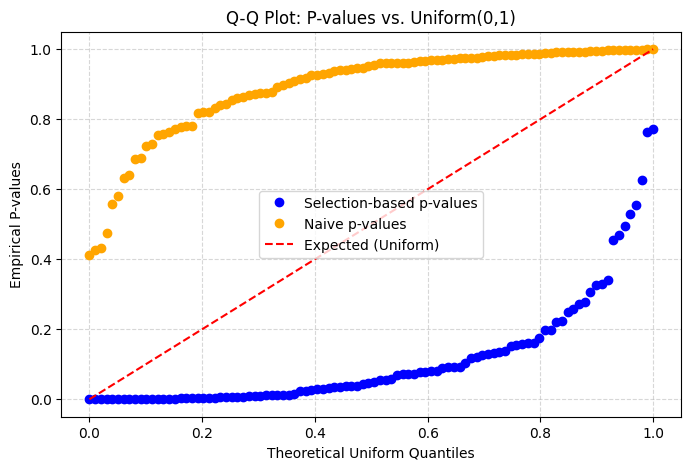

In [84]:
check_p_value_uniformity(20,15,1,19,1,-1,100)

level:  1
-5.953430953546688
level:  1
-5.918415251688836
level:  1
-5.807449591686842
level:  1
-5.915730866135025
level:  1
-5.847341758964905
level:  1
-5.920512551472791
level:  1
-5.834492977672216
level:  1
-5.777682327491377
level:  1
-5.859740702449299
level:  1
-5.949834556770279
level:  1
-5.799577800479197
level:  1
-5.957126459625757
level:  1
-5.8248720380348376
level:  1
-5.839540166633486
level:  1
-5.7984799409476935
level:  1
-5.824262633699647
level:  1
-5.889510179234982
level:  1
-5.860394555367364
level:  1
-5.8901299547896215
level:  1
-5.810747736295406
level:  1
-5.812850404447378
level:  1
-5.764632948076432
level:  1
-5.901081792221447
level:  1
-5.890703278427624
level:  1
-5.853310299878849
level:  1
-5.786727095190874
level:  1
-5.947115501918756
level:  1
-5.908951522122971
level:  1
-5.8222673266449565
level:  1
-5.875967199016218
level:  1
-5.867689410943708
level:  1
-5.919583560008602
level:  1
-5.877415323649341
level:  1
-5.893952473753313
level:  1


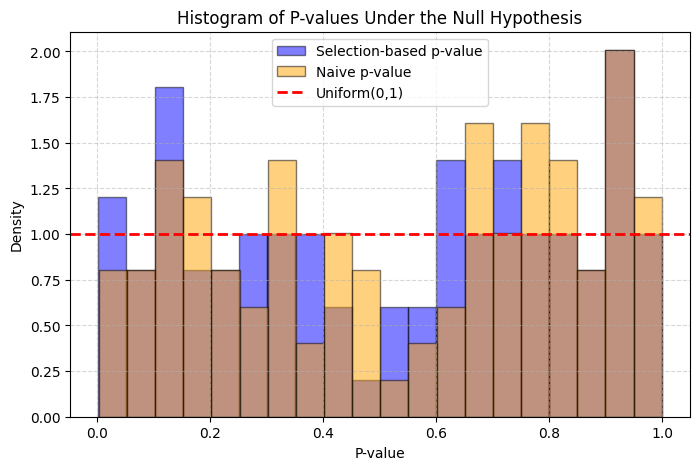

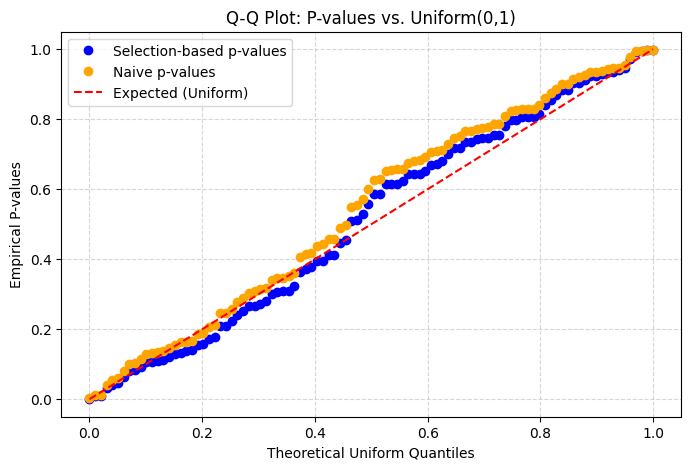

In [87]:
check_p_value_uniformity(20,2,1,19,10,-1,100)

level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  17
level:  16
level:  15
level:  14
level:  13
level:  12
level:  11
level:  10
level:  9
level:  8
le

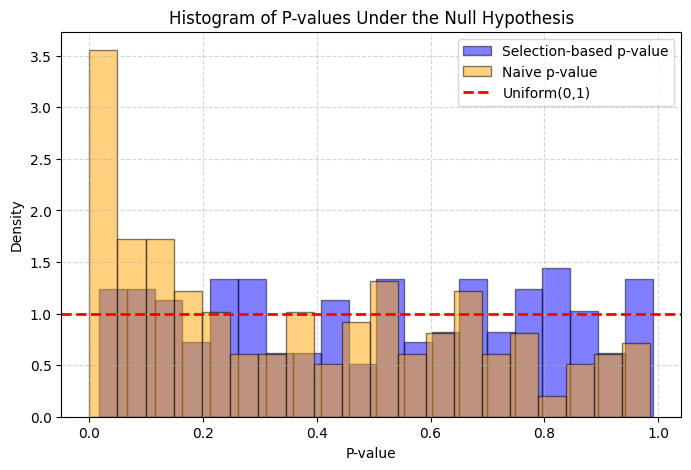

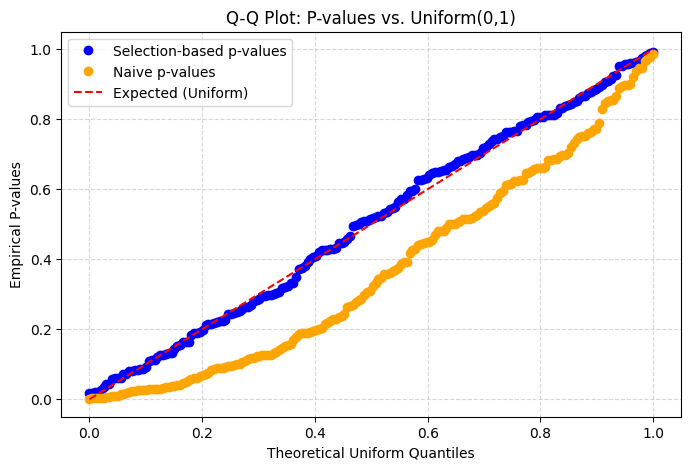

In [31]:
check_p_value_uniformity(20,2,1,3,np.log(20),-1,200)

In [ ]:
check_p_value_uniformity(20,30,1,19,np.log(20),-1,200)

In [ ]:
np.log(20)

level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6
level:  5
level:  4
level:  3
level:  2
level:  1
level:  7
level:  6


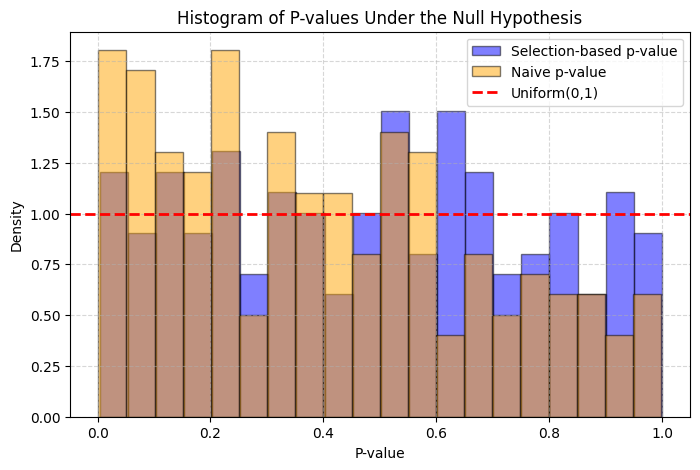

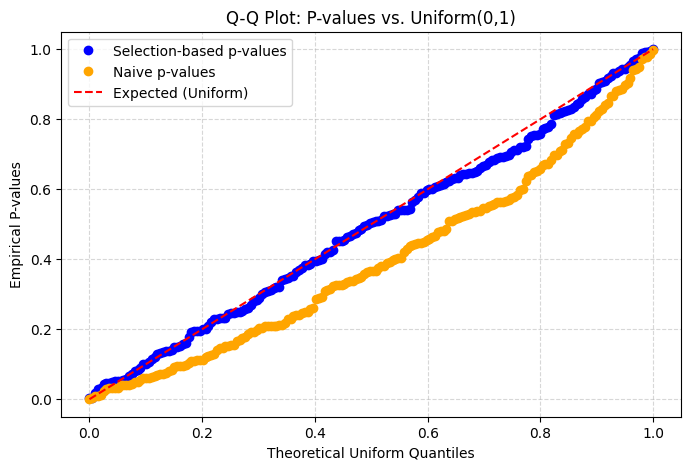

In [35]:
check_p_value_uniformity(10,15,1,3,np.log(10),-1,200)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


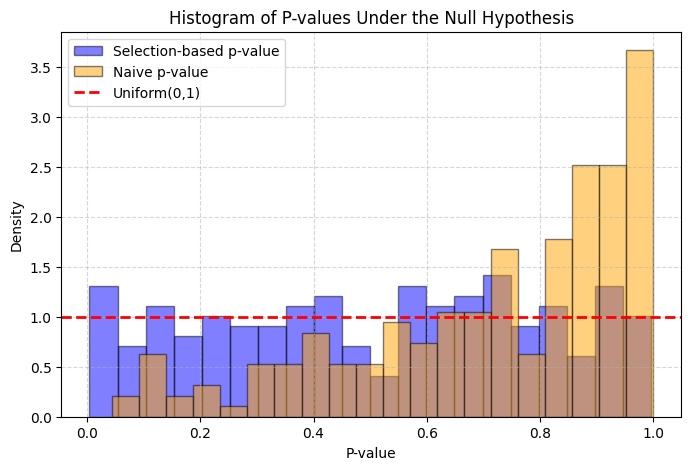

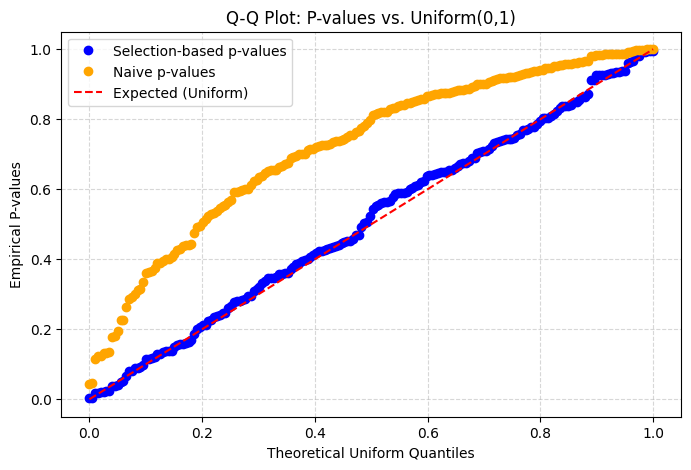

In [37]:
check_p_value_uniformity(20,15,1,19,np.log(20),-1,200)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


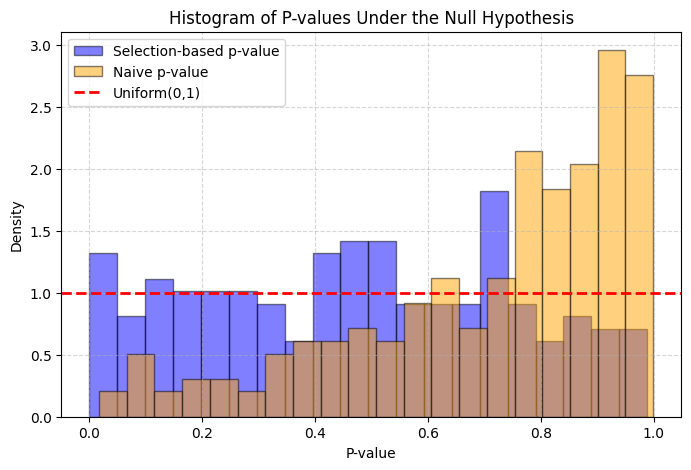

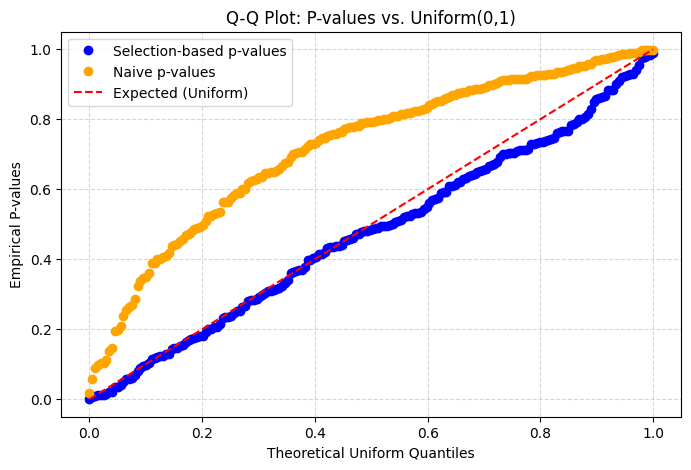

In [26]:
check_p_value_uniformity(30,15,1,29,np.log(30),-1,200)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


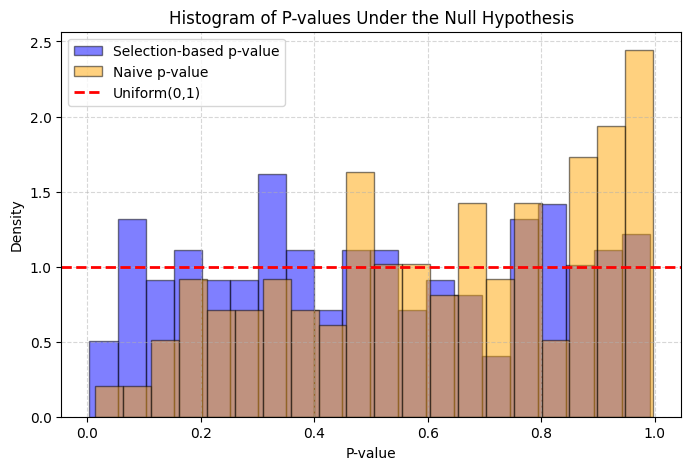

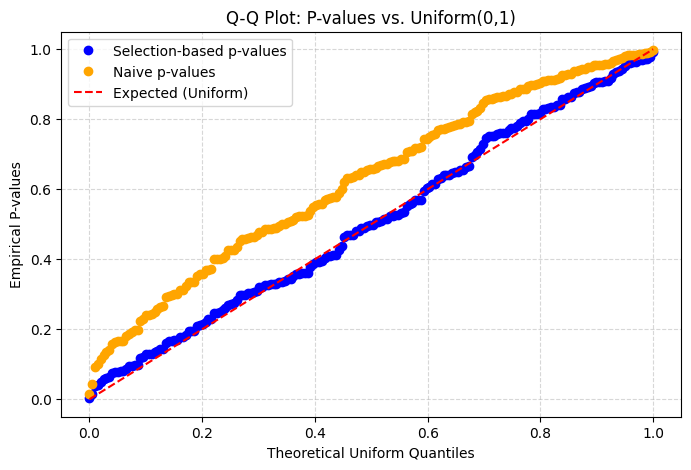

In [28]:
check_p_value_uniformity(30,15,1,29,np.sqrt(30),-1,200)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


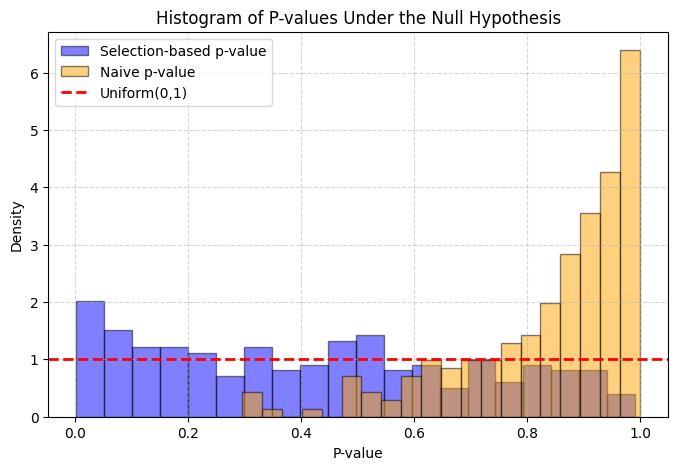

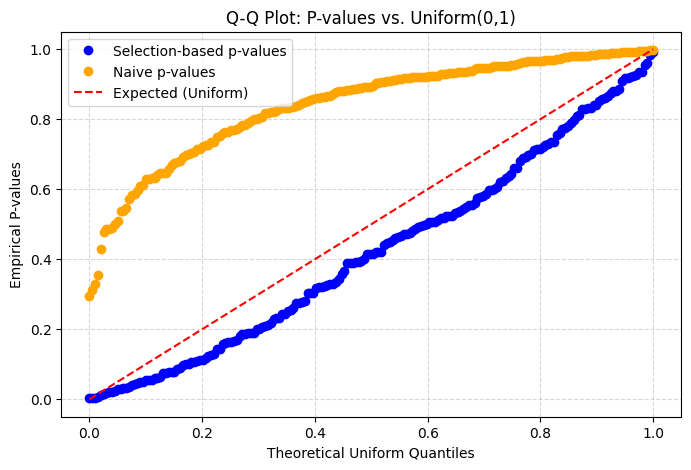

In [51]:
check_p_value_uniformity(10,2,1,9,1,-1,200)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


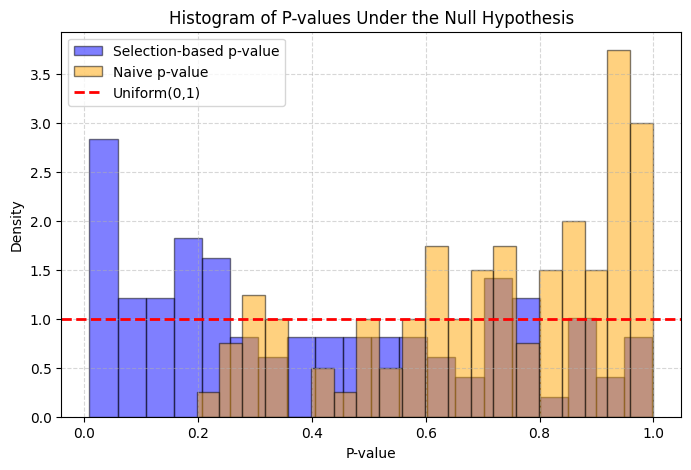

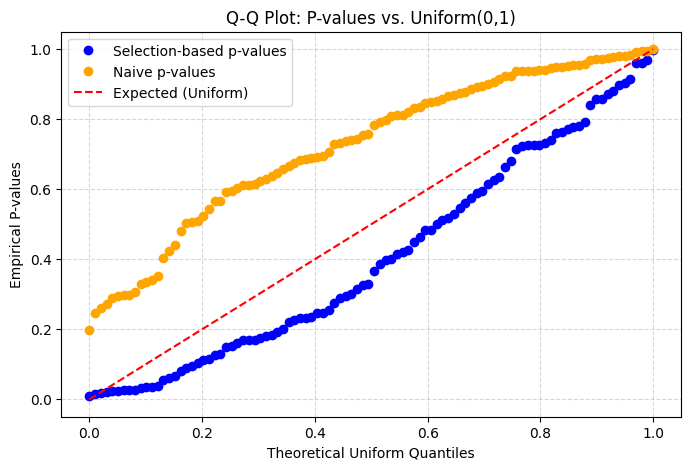

In [48]:
check_p_value_uniformity(20,2,1,19,2,-1,100)

level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1
level:  1


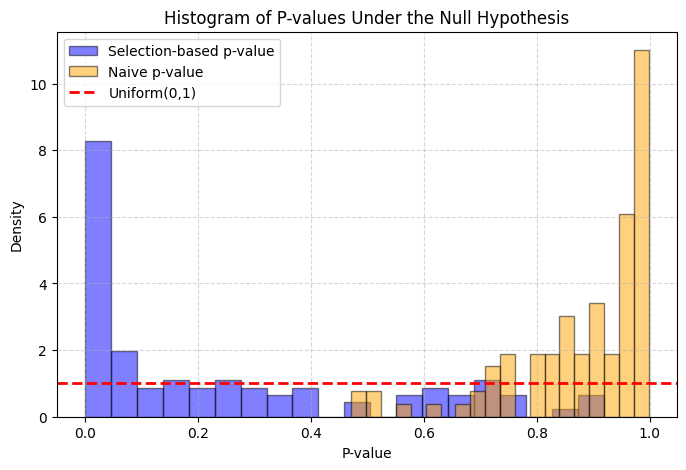

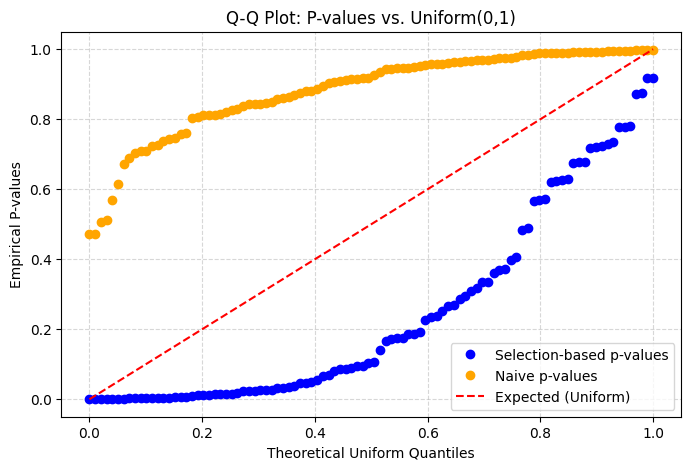

In [50]:
check_p_value_uniformity(30,2,1,29,1,-1,100)

In [ ]:
check_p_value_uniformity(20,2,1,19,5,-1,100)

In [ ]:
check_p_value_uniformity(100,30,1,99,5,-1,50)

In [ ]:
check_p_value_uniformity(20,15,1,10,1*np.sqrt(20),-1,100)

In [ ]:
check_p_value_uniformity(30,15,1,10,1*np.sqrt(30),-1,100)

In [ ]:
check_p_value_uniformity(30,15,1,3,1*np.sqrt(30),-1,200)

In [ ]:
def plot_p_value(stat_grid, cdf, observed_target, p_value):
    observed_cdf_value = np.interp(observed_target, stat_grid, cdf)
    
    plt.figure(figsize=(8, 5))
    
    plt.plot(stat_grid, cdf, label="CDF", color="blue", lw=2)
    plt.axvline(observed_target, color='red', linestyle='dashed', lw=2, label="Observed Target")
    
    plt.fill_between(stat_grid, cdf, 1, where=(stat_grid >= observed_target), color='red', alpha=0.3, label="p-value region")

    plt.text(observed_target, 0.05, f"Observed Target = {observed_target:.3f}", color='red', fontsize=12, rotation=90, verticalalignment='bottom')
    plt.text(stat_grid[-1]*0.85, 0.8, f"p-value = {p_value:.4f}", color='red', fontsize=14, bbox=dict(facecolor='white', edgecolor='red'))

    plt.xlabel(r"$X$ (Test Statistic)")
    plt.ylabel("Cumulative Probability (CDF)")
    plt.title("Visualization of p-value")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
  
    plt.show()

In [ ]:
grid = np.linspace(0.00001, 15, num=1000)

In [ ]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[-1]
node = key[0].parent
pvalue, obs, cdf = model.merge_inference(node)
pvalue

In [ ]:
plot_p_value(grid, cdf, obs, pvalue)

In [ ]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[-1]
node = key[0].parent
pvalue, obs, cdf = model.merge_inference(node)
pvalue

In [ ]:
plot_p_value(grid, cdf, obs, pvalue)

In [ ]:
print("\nExisting Clusters Log:")
for key, value in model.existing_clusters_log.items():
    print(f"Merge: {key} -> Clusters: {value}")

In [ ]:
X, y = make_blobs(n_samples=50, centers=4, cluster_std=1,random_state=42)

# Fit agglomerative clustering
model = AgglomerativeClustering(X, tau=1, n_clusters=3,linkage="single")
model.fit()
# Create an array to hold the assigned cluster labels
cluster_labels = np.zeros(X.shape[0], dtype=int)

# Assign cluster labels from the final cluster nodes
for idx, node in enumerate(model.cluster_nodes):
    for point_index in node.points:
        cluster_labels[point_index] = idx

    # Visualize the clusters
plt.scatter(X[:, 0], X[:, 1], s=50, c=cluster_labels, cmap='viridis', label='Data Points')
plt.title('Agglomerative Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster Label')
for i in range(len(X)):
    plt.annotate(str(i), (X[i, 0], X[i, 1]), fontsize=12, ha='right')

plt.show()

In [ ]:
pvalue

In [ ]:
plot_p_value(grid, cdf, obs, pvalue)

In [ ]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[3]
node = key[0].parent
pvalue, obs, cdf = model.merge_inference(node)
pvalue

In [ ]:
plot_p_value(grid, cdf, obs, pvalue)

In [ ]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[0]
node = key[0].parent

In [ ]:
node

In [ ]:
model.merge_inference(node)

In [ ]:
model.existing_clusters_log.keys()

In [ ]:
model.distance_matrix

In [ ]:
print("Distance Log:")
for key, value in model.distance_log.items():
    print(f"{key}: {value}")

In [ ]:
print("\nExisting Clusters Log:")
for key, value in model.existing_clusters_log.items():
    print(f"Merge: {key} -> Clusters: {value}")

In [ ]:
print("Randomization Log:")
for key, value in model.randomization_log.items():
    print(f"{key}: {value}")


In [ ]:
model.get_all_winning_pairs()

In [ ]:
np.random.normal(0,1,(10,1))

In [ ]:
X_grid = np.array([
    [-3.41284633,  8.94302295],
    [-6.63766492, -8.79338984],
    [-5.46153354,  8.71814827],
    [-5.59752253,  8.4386312],
    [ 4.17646114,  1.50743993]
])


In [ ]:
from scipy.spatial import distance
data_new_node = X_grid[3,:].reshape(1,-1)
data_cluster = X_grid[[0,2],:]
distances = distance.cdist(data_new_node, data_cluster, metric='euclidean')
        

In [ ]:
distances

In [ ]:
from scipy.spatial import distance
data_new_node = X_grid[0,:].reshape(1,-1)
data_cluster = X_grid[2,:].reshape(1,-1)
distances = distance.cdist(data_new_node, data_cluster, metric='euclidean')
distances

In [ ]:
data_new_node = X[3,:].reshape(1,-1)
data_cluster = X[[0,2],:]
distances = distance.cdist(data_new_node, data_cluster, metric='euclidean')
distances

In [ ]:
data_new_node = X[0,:].reshape(1,-1)
data_cluster = X[2,:].reshape(1,-1)
distances = distance.cdist(data_new_node, data_cluster, metric='euclidean')
distances